In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
    "../data/processed/cleaned_nav_history.csv"
)

performance = pd.read_csv(
    "../data/processed/cleaned_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../data/processed/cleaned_10_benchmark_indices.csv"
)

fund_master = pd.read_csv(
    "../data/processed/cleaned_01_fund_master.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


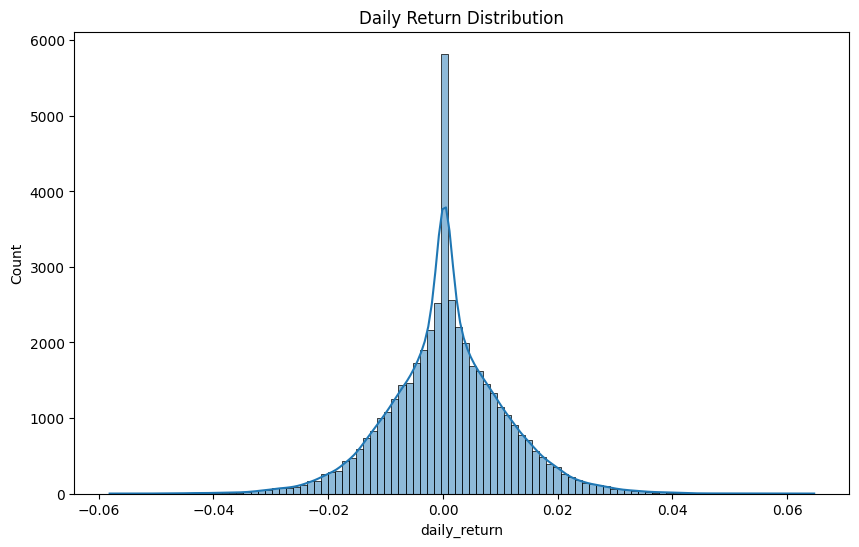

In [4]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [5]:
nav.to_csv(
    "../data/processed/nav_with_returns.csv",
    index=False
)

print("Daily returns saved")

Daily returns saved


In [6]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] -
         df.iloc[0]["date"]).days
        / 365.25
    )

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_results.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026371
1,100025,0.044582
2,100033,0.301232
3,101206,0.235384
4,101207,0.079388


In [7]:
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code",
         "scheme_name"]
    ],
    on="amfi_code"
)

cagr_df.sort_values(
    "cagr",
    ascending=False
).head(10)

,amfi_code,cagr,scheme_name
25,120505,0.328274,ICICI Pru Midcap Fund - Regular - Growth
21,119598,0.324235,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.322874,DSP Small Cap Fund - Regular - Growth
36,148569,0.319495,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,0.309741,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.309075,Kotak Flexicap Fund - Regular - Growth
2,100033,0.301232,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,0.295811,DSP Midcap Fund - Regular - Growth
16,119094,0.282144,Axis Midcap Fund - Regular - Growth
19,119551,0.258047,SBI Bluechip Fund - Regular Plan - Growth


In [8]:
rf = 0.065

In [9]:
sharpe_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    annual_return = (
        returns.mean() * 252
    )

    annual_std = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_std

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [10]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    annual_return = (
        returns.mean() * 252
    )

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [11]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [12]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][
        ["date",
         "daily_return"]
    ]

    merged = pd.merge(
        fund_df,
        nifty100[
            ["date",
             "benchmark_return"]
        ],
        on="date"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r, p, se = (
            linregress(
                merged[
                    "benchmark_return"
                ],
                merged[
                    "daily_return"
                ]
            )
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append(
            [fund,
             alpha,
             beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [13]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [14]:
drawdowns = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    df["running_max"] = (
        df["nav"].cummax()
    )

    df["drawdown"] = (
        df["nav"]
        / df["running_max"]
        - 1
    )

    max_dd = (
        df["drawdown"]
        .min()
    )

    drawdowns.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [15]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund scorecard saved")

NameError: name 'scorecard' is not defined

In [16]:
print(sharpe_df.shape)
print(alpha_beta_df.shape)
print(drawdown_df.shape)
print(performance.shape)

(40, 2)
(40, 3)
(40, 2)
(40, 19)


In [17]:
scorecard = (
    performance[
        ["amfi_code",
         "return_3yr_pct",
         "expense_ratio_pct"]
    ]
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        drawdown_df,
        on="amfi_code"
    )
)

print(scorecard.shape)

scorecard.head()

(40, 7)


,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,beta,max_drawdown
0,119551,12.36,1.54,1.208267,0.232010,-0.031751,-0.150124
1,119552,11.30,0.66,0.953279,0.198686,-0.026159,-0.118035
2,119598,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060
3,119599,23.14,0.72,-0.057187,0.048824,0.062002,-0.525742
4,119120,6.07,0.77,-0.226575,0.056209,-0.006414,-0.043287


In [18]:
alpha_beta_df.head()
alpha_beta_df.shape

(40, 3)

In [19]:
alpha_beta_df.shape

(40, 3)

In [20]:
print(sharpe_df.shape)
print(alpha_beta_df.shape)
print(drawdown_df.shape)
print(performance.shape)

(40, 2)
(40, 3)
(40, 2)
(40, 19)


In [21]:
scorecard = (
    performance[
        ["amfi_code",
         "return_3yr_pct",
         "expense_ratio_pct"]
    ]
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        drawdown_df,
        on="amfi_code"
    )
)

scorecard["score"] = (

    scorecard["return_3yr_pct"].rank(pct=True) * 30 +

    scorecard["sharpe_ratio"].rank(pct=True) * 25 +

    scorecard["alpha"].rank(pct=True) * 20 +

    (
        1 -
        scorecard["expense_ratio_pct"].rank(pct=True)
    ) * 15 +

    (
        1 -
        scorecard["max_drawdown"].rank(pct=True)
    ) * 10

)

print(scorecard.shape)

scorecard.sort_values(
    "score",
    ascending=False
).head()

(40, 8)


,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,beta,max_drawdown,score
2,119598,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060,82.7500
12,120505,18.08,1.36,1.180101,0.292636,0.000549,-0.181885,81.6250
39,149324,20.08,1.52,0.949796,0.300579,0.011455,-0.311719,77.3125
7,100033,16.58,1.38,1.093699,0.271954,0.005104,-0.162172,75.3750
22,120843,15.65,1.45,1.306744,0.273305,-0.022830,-0.129740,74.6250


In [22]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund scorecard saved")

Fund scorecard saved


In [23]:
print(scorecard.shape)

(40, 8)


In [24]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund scorecard saved")

Fund scorecard saved


In [25]:
top5 = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
    .head(5)
)

top5

,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,beta,max_drawdown,score
2,119598,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060,82.7500
12,120505,18.08,1.36,1.180101,0.292636,0.000549,-0.181885,81.6250
39,149324,20.08,1.52,0.949796,0.300579,0.011455,-0.311719,77.3125
7,100033,16.58,1.38,1.093699,0.271954,0.005104,-0.162172,75.3750
22,120843,15.65,1.45,1.306744,0.273305,-0.022830,-0.129740,74.6250


In [26]:
top5_codes = list(top5["amfi_code"])

top5_names = fund_master[
    fund_master["amfi_code"].isin(top5_codes)
][["amfi_code","scheme_name"]]

top5_names

,amfi_code,scheme_name
2,119598,SBI Small Cap Fund - Regular Plan - Growth
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
12,120505,ICICI Pru Midcap Fund - Regular - Growth
22,120843,Kotak Flexicap Fund - Regular - Growth
39,149324,DSP Small Cap Fund - Regular - Growth


In [27]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

# Normalize to 100
nifty50["normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

nifty100["normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

print("Benchmark Prepared")

Benchmark Prepared


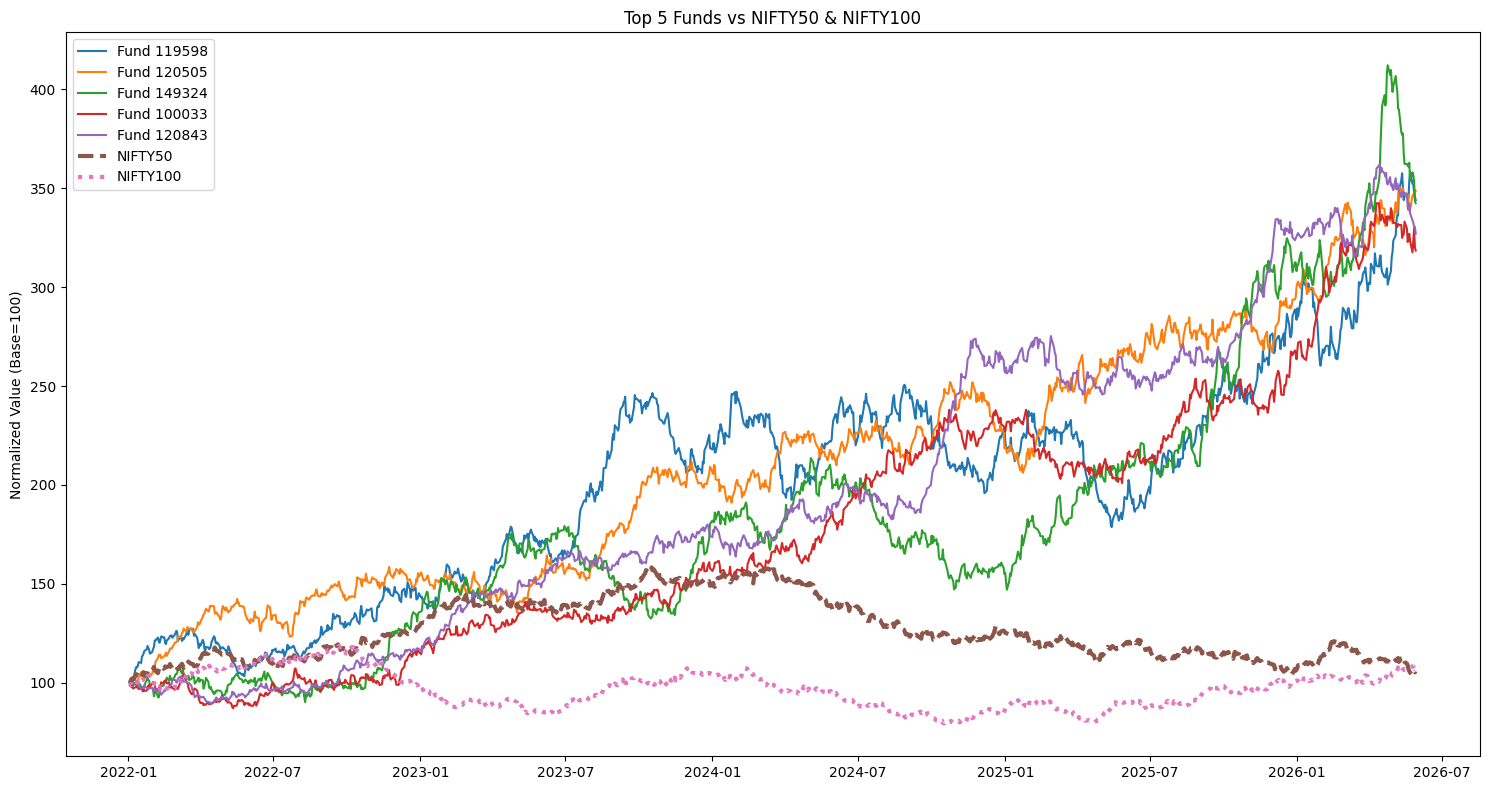

In [28]:
plt.figure(figsize=(15,8))

# Plot Top 5 Funds

for fund in top5_codes:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    df = df.sort_values("date")

    df["normalized"] = (
        df["nav"] /
        df["nav"].iloc[0]
    ) * 100

    plt.plot(
        df["date"],
        df["normalized"],
        label=f"Fund {fund}"
    )

# NIFTY 50

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    linestyle="--",
    label="NIFTY50"
)

# NIFTY 100

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    linestyle=":",
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.ylabel("Normalized Value (Base=100)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [33]:
tracking_errors = []

for fund in top5_codes:

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date"
    ).dropna()

    tracking_error = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
        *
        np.sqrt(252)
    )

    tracking_errors.append(
        [fund, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,119598,0.283881
1,120505,0.231968
2,149324,0.279170
3,100033,0.228699
4,120843,0.206425


In [34]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error Saved")

Tracking Error Saved


In [30]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'normalized'], dtype='str')


In [31]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [35]:
nav["date"].min(), nav["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [36]:
from datetime import timedelta

latest_date = nav["date"].max()

cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    # 1 Year CAGR
    one_year_start = latest_date - pd.DateOffset(years=1)

    one_year_data = fund_df[
        fund_df["date"] >= one_year_start
    ]

    cagr_1y = np.nan

    if len(one_year_data) > 1:

        start_nav = one_year_data.iloc[0]["nav"]
        end_nav = one_year_data.iloc[-1]["nav"]

        cagr_1y = (
            (end_nav / start_nav)
            ** (1/1)
            - 1
        )

    # 3 Year CAGR
    three_year_start = latest_date - pd.DateOffset(years=3)

    three_year_data = fund_df[
        fund_df["date"] >= three_year_start
    ]

    cagr_3y = np.nan

    if len(three_year_data) > 1:

        start_nav = three_year_data.iloc[0]["nav"]
        end_nav = three_year_data.iloc[-1]["nav"]

        cagr_3y = (
            (end_nav / start_nav)
            ** (1/3)
            - 1
        )

    cagr_results.append([
        fund,
        cagr_1y,
        cagr_3y
    ])

cagr_periods = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr"
    ]
)

cagr_periods.head()

,amfi_code,cagr_1yr,cagr_3yr
0,100016,-0.022243,0.012926
1,100025,0.037050,0.039164
2,100033,0.532324,0.324425
3,101206,0.479241,0.289677
4,101207,-0.239860,-0.041524


In [37]:
cagr_periods.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison saved")

CAGR comparison saved
